# **Missing_Values_Analysis**

## **Libraries & Database Connectioin**

In [1]:
# import the necessary libraries.

import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine, text  # for database connection
from IPython.display import display         # for better presentation
import warnings
warnings.filterwarnings("ignore")           # ignore all warnings

In [ ]:
# Connection parameters

user_name=''
password=''
host = 'localhost'
port = '5433'
database = 'layereddb'
schema='berlin_source_data'

# Connection to the db.
engine = create_engine(f'postgresql+psycopg2://{user_name}:{password}@{host}:{port}/{database}')

## **1. Check all tables in the berlin_source_data schema for missing or null values.**

### **1.1. Data Loading**

In [3]:
# Define a function for data loading

def load_data(table_name):
    '''
    Retrieve data from the database and load it into a DataFrame
    '''
    query = f"SELECT * FROM berlin_source_data.{table_name};"
    df = pd.read_sql_query(sql = text(query), con = engine)

    # print(f"Succesfully loaded the tabe {table_name}. Rows: {df.shape[0]}\n")
    return df

In [4]:
# Grab the list of tables from the database metadata
query = "SELECT table_name FROM information_schema.tables WHERE table_schema = 'berlin_source_data';"

# Execute the query and convert the column to a clean list
table_names = pd.read_sql_query(sql=text(query), con=engine)['table_name'].tolist()

print(table_names)

['tram_stops', 'bus_stops', 'long_term_listings', 'public_artworks', 'spaetis', 'galleries', 'kindergartens', 'museums', 'ubahn', 'hospitals', 'gyms', 'recycling_points', 'pools', 'neighborhoods', 'government_offices', 'social_clubs_activities', 'short_term_listings', 'food_markets', 'doctors', 'malls', 'libraries', 'theaters', 'supermarkets', 'religious_institutions', 'pharmacies', 'parking_spaces', 'post_offices', 'night_clubs', 'districts', 'schools', 'parks', 'exhibition_centers', 'bike_lanes', 'venues', 'playgrounds', 'dental_offices', 'milieuschutz_protection_zones', 'sbahn', 'universities', 'petstores', 'banks']


**CONTAINER**

In [5]:

# Create a container for all the tables
all_dfs = {}

# Loop through the list and load each one
for name in table_names:
    
    all_dfs[name] = load_data(name)

In [6]:
# Check if works
df_banks = all_dfs["banks"]
df_banks.head(2)

,id,name,brand,operator,street,housenumber,postcode,opening_hours,atm,wheelchair,latitude,longitude,district,district_id,neighborhood,neighborhood_id,geometry
0,5774792924,deutsche bank,deutsche bank,nan,nan,nan,nan,unknown,unknown,true,52.537245,13.206002,Spandau,11005005,Spandau,0501,POINT(13.206002 52.537245)
1,5945635506,postbank,postbank,nan,nan,nan,nan,mo-fr 09:00-18:30; sa 09:00-13:00 || mo-fr 09:...,unknown,unknown,52.485604,13.354659,Tempelhof-Schöneberg,11007007,Schöneberg,0701,POINT(13.354659 52.485604)


### **1.2. Checking for NaN or NULL**

In [7]:
# Define a function for NaN or NULL checking.

def check_na(data_frame):
    '''
    Take a Data Frame as input and outpu a dictionary containing columns with each total number of missing value in case there are.
    '''
    all_na = data_frame.isna().sum()    # Create a pandas series from which we will take only the col with na.
    dict_mis_val = {col: val for col, val in all_na.items() }
    return dict_mis_val


In [8]:
#  Check if the check_na works
banks_na = check_na(df_banks)
banks_na

{'id': 0,
 'name': 0,
 'brand': 0,
 'operator': 0,
 'street': 0,
 'housenumber': 0,
 'postcode': 0,
 'opening_hours': 0,
 'atm': 0,
 'wheelchair': 0,
 'latitude': 0,
 'longitude': 0,
 'district': 0,
 'district_id': 0,
 'neighborhood': 0,
 'neighborhood_id': 84,
 'geometry': 0}

## **2. Evaluate missing values, including hidden anomalies:**

### **2.1. Identify cells where missing values are stored as strings like 'unknown' or 'None' instead of NULL**


In [9]:
# Define a function for other type of missing value checking.
## Since the .isna() and .isnull() cannot catch the string "unknown" or "none", we have to check those other types of missing value.

def check_other_missing_val(data_frame):
    '''
    Takes a data_frame as input, for string columns, adds the column's name and its total number of other missing value 
    to the ad-hoc dictionary dict_other_mis_val if that total number is greater than zero.
    '''
    dict_other_mis_val = {}

    for col in data_frame:
        # Mathces all the case-insensitive of each type ofmissing value
        mask = data_frame[col].replace(r'(?i)^(unknown|none|n/a|null|nan)$', True, regex = True) == True
        dict_other_mis_val[col] = int(mask.sum())
    return dict_other_mis_val

In [10]:
# Check if the function check_other_missing_val works.
banks_other_mis_val = check_other_missing_val(df_banks)
banks_other_mis_val

{'id': 0,
 'name': 1,
 'brand': 129,
 'operator': 149,
 'street': 90,
 'housenumber': 99,
 'postcode': 95,
 'opening_hours': 45,
 'atm': 74,
 'wheelchair': 82,
 'latitude': 0,
 'longitude': 0,
 'district': 0,
 'district_id': 0,
 'neighborhood': 0,
 'neighborhood_id': 0,
 'geometry': 0}

In [11]:
# Just in case we are asked to convert the other missing value in NaN

df_banks_copy = df_banks.copy().replace(r'(?i)^(unknown|none)$', np.nan, regex=True)
df_banks_copy.isin(["unknown", "None"]).sum()

id                 0
name               0
brand              0
operator           0
street             0
housenumber        0
postcode           0
opening_hours      0
atm                0
wheelchair         0
latitude           0
longitude          0
district           0
district_id        0
neighborhood       0
neighborhood_id    0
geometry           0
dtype: int64

### **2.2. Check for 0s that were inserted where a value should have been missing**

In [12]:
# Berlin not being crossed by neither the equator (latitude = 0) nor the 0 meridiant (longitude = 0), any of those two columns shouldn't contain 0.
# as well as categorical column should not contain '0's

def check_zero(data_frame):
    '''
    Takes a data frame as input and return a dictionary of columns each paired with its total number of 0 (numerical column) 
    or '0' (for categorical column) if and only if that total number is greater than zero.
    '''
    dict_zero = {}
    for col in data_frame: # Adding 'category' ensures that the code doesn't breack later on if the data type are optimized for performance.
        if pd.api.types.is_object_dtype(data_frame[col]):   # Account for eventual future numerical columns which shouldn't take 0 as entry.
            mask = data_frame[col] == '0'
        else:
            mask = data_frame[col] == 0
        dict_zero[col] = int(mask.sum())
    return dict_zero


In [13]:
# Check if the function check_zero works.
banks_false_zero = check_zero(df_banks)
banks_false_zero

{'id': 0,
 'name': 0,
 'brand': 0,
 'operator': 0,
 'street': 0,
 'housenumber': 0,
 'postcode': 0,
 'opening_hours': 0,
 'atm': 0,
 'wheelchair': 0,
 'latitude': 0,
 'longitude': 0,
 'district': 0,
 'district_id': 0,
 'neighborhood': 0,
 'neighborhood_id': 0,
 'geometry': 0}

### **2.3. Determine whether missing values are acceptable (e.g., email not provided by a school) or indicate a potential data quality issue (e.g., 0 in a statistics table that should be Null)**

In [14]:
# Get to be done with real data.
def mis_value_quality(data_frame):
    '''
    Takes a data_frame as input, and outputs another df whose rows corrispond to the columns of th input data_frame.
    Two of its columns are directly filled in to avoid redondant back-and-forth.
    '''
    # The name of rows in the new df correspond to the name of columns in the input data_frame.
    assessment_df = pd.DataFrame(index = data_frame.columns)       
    
    # Retrieve the outputs of other functions and use them as input here.
    data_frame_na = check_na(data_frame)
    data_frame_other_mis_val = check_other_missing_val(data_frame)
    data_frame_false_zero = check_zero(data_frame)

    # 1. We count the NaN
    assessment_df["NaN_count"] = pd.Series(data_frame_na).fillna(0).astype(int)

    # 2. We count the other missing.
    assessment_df["other_mis_val_count"] = pd.Series(data_frame_other_mis_val).fillna(0).astype(int)

    # 3. We count the zero_missing.
    assessment_df["zero_count"] = pd.Series(data_frame_false_zero).fillna(0).astype(int) 

    # 4. Compute the sum of missing values
    assessment_df["total_count"] = assessment_df["other_mis_val_count"] + assessment_df["zero_count"] + assessment_df["NaN_count"]

    # 5. Calculate the % of missing value
    total_rows = len(data_frame) if len(data_frame) > 0 else 1
    assessment_df["%_all_missing_value"] = np.round((assessment_df["total_count"] / total_rows)*100, 2)
    
    # 6. Create the other columns
    assessment_df["NaN_count_status"] = ""
    assessment_df["other_mis_val_count_status"] = ""           
    assessment_df["zero_count_status"] = ""              
    assessment_df["potential_issue"] = ""                       
    assessment_df["note"] = ""                                  
    
    return assessment_df

In [15]:
# Check if the function mis_value_quality works.
banks_assessment = mis_value_quality(df_banks)
banks_assessment

,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
id,0,0,0,0,0.00,,,,,
name,0,1,0,1,0.31,,,,,
brand,0,129,0,129,39.94,,,,,
operator,0,149,0,149,46.13,,,,,
street,0,90,0,90,27.86,,,,,
housenumber,0,99,0,99,30.65,,,,,
postcode,0,95,0,95,29.41,,,,,
opening_hours,0,45,0,45,13.93,,,,,
atm,0,74,0,74,22.91,,,,,
wheelchair,0,82,0,82,25.39,,,,,


In [16]:
def fill_col(df_assessment):
    
    # This helper funciton just flags if we have a clean status (0) or if we need to actually look at the data
    def check_zero(cel_value):
        if cel_value == 0:
            return "Clean"
        return "Requires Review"
    
    # Pre-filling the status columns so we can use them for the logic below
    df_assessment["NaN_count_status"] = df_assessment["NaN_count"].apply(check_zero)
    df_assessment["other_mis_val_count_status"] = df_assessment["other_mis_val_count"].apply(check_zero)
    df_assessment["zero_count_status"] = df_assessment["zero_count"].apply(check_zero)

    # Defining the funtion which will help to fill in the 'potential_issue' column.
    def issue_value(row):
        if row["zero_count_status"] == "Requires Review":
            return "Data Quality Issue"
        elif row["other_mis_val_count_status"] == "Requires Review":
            return "Need to be converted in NaN"
        elif row["NaN_count_status"] == "Requires Review":
            return "Natural"
        else:
            return "Nothing to report"

    # Apply the function to the column 'potential_issue'
    df_assessment["potential_issue"] = df_assessment.apply(issue_value, axis = 1)

    # Defining the funtion which will help to fill in the 'note' column.
    def note_value(row):
        if row["zero_count_status"] == "Requires Review":
            return "Unexpected 0s and/or '0's"
        elif row["other_mis_val_count_status"] == "Requires Review":
            return "Wrong Data Entry"
        elif row["NaN_count_status"] == "Requires Review":
            return "Missing due to lack of data"
        else:
            return "Nothing to report"
    # Apply the function to the column 'note'    
    df_assessment["note"] = df_assessment.apply(note_value, axis = 1)

    metadata_text = "-----VERY IMPORTANT METADATA-----: In the column 'potential_issue', \n \
    The value 'Natural' means: Missing values are labeled in an understandable way(NaN, None, UNKOWN, NULL, N/A); \n \
    The value 'Data Quality Issue' means: Missing values are labeled in a misleadimg way(zero instead of missing value\n"
    df_assessment.attrs["metadata"] = metadata_text
    
    return df_assessment

In [17]:
# Check if the function mis_value_quality works.
banks_assessment = fill_col(banks_assessment)
banks_assessment

,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
id,0,0,0,0,0.00,Clean,Clean,Clean,Nothing to report,Nothing to report
name,0,1,0,1,0.31,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
brand,0,129,0,129,39.94,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
operator,0,149,0,149,46.13,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
street,0,90,0,90,27.86,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
housenumber,0,99,0,99,30.65,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
postcode,0,95,0,95,29.41,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
opening_hours,0,45,0,45,13.93,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
atm,0,74,0,74,22.91,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
wheelchair,0,82,0,82,25.39,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry


### **2.4. Table Report Pipeline**

In [18]:
# Storing every report in a dict to keep it organized.
all_reports = {}

# IN ORDER TO UPDATE THE TABLES, WE NEED TO RUN THE CONTAINER BEFORE RUNING THE PIPELINE.
for name, df in all_dfs.items():
    print(f"Checking table: {name}...")
    
    # We can generate the report by calling the function "mis_value_quality" because 
    # it already runs the 3 previous functions(check_na, check_other_missing_val and check_zero).
    report = mis_value_quality(df)
    
    # populate the other columns of the report.
    report = fill_col(report)
    
    # Save results to the dictionary.
    all_reports[name] = report

print("\nDone. All tables audited.")

Checking table: tram_stops...
Checking table: bus_stops...
Checking table: long_term_listings...
Checking table: public_artworks...
Checking table: spaetis...
Checking table: galleries...
Checking table: kindergartens...
Checking table: museums...
Checking table: ubahn...
Checking table: hospitals...
Checking table: gyms...
Checking table: recycling_points...
Checking table: pools...
Checking table: neighborhoods...
Checking table: government_offices...
Checking table: social_clubs_activities...
Checking table: short_term_listings...
Checking table: food_markets...
Checking table: doctors...
Checking table: malls...
Checking table: libraries...
Checking table: theaters...
Checking table: supermarkets...
Checking table: religious_institutions...
Checking table: pharmacies...
Checking table: parking_spaces...
Checking table: post_offices...
Checking table: night_clubs...
Checking table: districts...
Checking table: schools...
Checking table: parks...
Checking table: exhibition_centers...

In [19]:
# Check if the pipeline works.
banks_assessment_2 = all_reports["banks"]
print(banks_assessment_2.attrs["metadata"])
banks_assessment_2

-----VERY IMPORTANT METADATA-----: In the column 'potential_issue', 
     The value 'Natural' means: Missing values are labeled in an understandable way(NaN, None, UNKOWN, NULL, N/A); 
     The value 'Data Quality Issue' means: Missing values are labeled in a misleadimg way(zero instead of missing value



,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
id,0,0,0,0,0.00,Clean,Clean,Clean,Nothing to report,Nothing to report
name,0,1,0,1,0.31,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
brand,0,129,0,129,39.94,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
operator,0,149,0,149,46.13,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
street,0,90,0,90,27.86,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
housenumber,0,99,0,99,30.65,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
postcode,0,95,0,95,29.41,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
opening_hours,0,45,0,45,13.93,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
atm,0,74,0,74,22.91,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
wheelchair,0,82,0,82,25.39,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry


In [20]:
# Parity Check: Let's see if we can validate out pipeline or not.
print((banks_assessment_2 != banks_assessment).sum())

NaN_count                     0
other_mis_val_count           0
zero_count                    0
total_count                   0
%_all_missing_value           0
NaN_count_status              0
other_mis_val_count_status    0
zero_count_status             0
potential_issue               0
note                          0
dtype: int64


## **3. Document findings for each table/column:**

### **3.1. Summary of missing values, including hidden anomalies**

In [21]:
def summary_report(list_df):
    '''
    Create the container of all summary report to keep them organized.
    '''
    all_summaries = {}
    
    for df in list_df:
        df_report = all_reports[df]
        df_summary = {
            "Total_Normale_Missingness": df_report["NaN_count"].sum(),
            "Total_Other_Missingness": df_report["other_mis_val_count"].sum(),
            "Total_Anormale_Missingness": df_report["zero_count"].sum(),
            "Total_All_Missingness": df_report["total_count"].sum()
        }
        # Each summary report has only one row and the index is the name of the table so we can keep track.
        all_summaries[df] = pd.DataFrame(df_summary, index = [df])
    return all_summaries

        

In [22]:
# Check if our function summary_report works
all_dfs_summary = summary_report(table_names)
all_dfs_summary

{'tram_stops':             Total_Normale_Missingness  Total_Other_Missingness  \
 tram_stops                        890                        0   
 
             Total_Anormale_Missingness  Total_All_Missingness  
 tram_stops                           0                    890  ,
 'bus_stops':            Total_Normale_Missingness  Total_Other_Missingness  \
 bus_stops                        303                        0   
 
            Total_Anormale_Missingness  Total_All_Missingness  
 bus_stops                           0                    303  ,
 'long_term_listings':                     Total_Normale_Missingness  Total_Other_Missingness  \
 long_term_listings                       1208                      367   
 
                     Total_Anormale_Missingness  Total_All_Missingness  
 long_term_listings                         145                   1720  ,
 'public_artworks':                  Total_Normale_Missingness  Total_Other_Missingness  \
 public_artworks               

In [23]:
# now let's create a data frame containing all those summary reports.
all_dfs_summary = pd.concat(all_dfs_summary.values())
all_dfs_summary = all_dfs_summary.reset_index()
all_dfs_summary = all_dfs_summary.rename(columns = {"index": "Name"}) # We want to have the column "Name"
all_dfs_summary

,Name,Total_Normale_Missingness,Total_Other_Missingness,Total_Anormale_Missingness,Total_All_Missingness
0,tram_stops,890,0,0,890
1,bus_stops,303,0,0,303
2,long_term_listings,1208,367,145,1720
3,public_artworks,7898,28,0,7926
4,spaetis,0,0,0,0
5,galleries,843,0,0,843
6,kindergartens,3745,76,0,3821
7,museums,1460,0,0,1460
8,ubahn,18,0,0,18
9,hospitals,379,1646,0,2025


In [24]:
# 
def summary_note(row):
        if row["Total_All_Missingness"] == 0:
            return "100% Ready"
        elif row["Total_Anormale_Missingness"] > 0:
            return "Some Data Quality Issue"
        elif row["Total_Other_Missingness"] > 0:
             return "Some Wrong Data Entry"
        else:
            return "Normal Missing Data"

In [25]:
# Apply the function to the column 'potential_issue'
all_dfs_summary["Finale_Note"] = all_dfs_summary.apply(summary_note, axis = 1)
all_dfs_summary

,Name,Total_Normale_Missingness,Total_Other_Missingness,Total_Anormale_Missingness,Total_All_Missingness,Finale_Note
0,tram_stops,890,0,0,890,Normal Missing Data
1,bus_stops,303,0,0,303,Normal Missing Data
2,long_term_listings,1208,367,145,1720,Some Data Quality Issue
3,public_artworks,7898,28,0,7926,Some Wrong Data Entry
4,spaetis,0,0,0,0,100% Ready
5,galleries,843,0,0,843,Normal Missing Data
6,kindergartens,3745,76,0,3821,Some Wrong Data Entry
7,museums,1460,0,0,1460,Normal Missing Data
8,ubahn,18,0,0,18,Normal Missing Data
9,hospitals,379,1646,0,2025,Some Wrong Data Entry


In [26]:
# We want to plot all_dfs_summary
table_readyness = np.round((all_dfs_summary.groupby("Finale_Note")["Name"].count() / len(all_dfs_summary))*100, 2)
table_readyness

Finale_Note
100% Ready                  7.32
Normal Missing Data        46.34
Some Data Quality Issue    24.39
Some Wrong Data Entry      21.95
Name: Name, dtype: float64

In [27]:
# We need to label the plot
table_readiness_labels = [label for label in table_readyness.index]
table_readiness_labels

['100% Ready',
 'Normal Missing Data',
 'Some Data Quality Issue',
 'Some Wrong Data Entry']

In [28]:
# We need colors for our plot.
my_colors = sns.set_palette("colorblind")

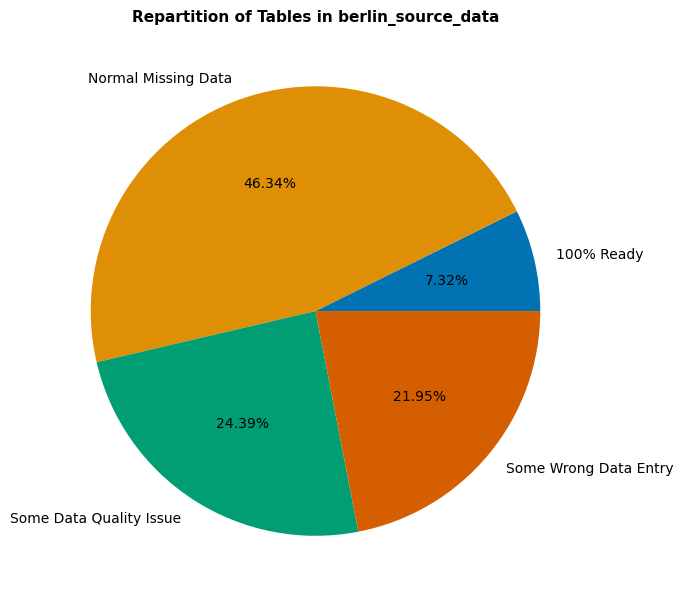

In [29]:
# Create the pie chart

plt.figure(figsize = (7, 7))
plt.pie(table_readyness, labels = table_readiness_labels, colors = my_colors, autopct = '%.2f%%')
plt.title("Repartition of Tables in berlin_source_data", fontsize = 11, fontweight = "bold")
plt.tight_layout()
plt.savefig("repartition_plot.png")
plt.show()

### **3.2. Assessment for each column:**


* 3.2.1. Columns in which missing values are natural and okay.

In [30]:
# Filter and show tables with normal missing values
normal_missing = {}

for name, report in all_reports.items():
    mask = report["potential_issue"] == "Natural"
    df_normal_mis = report[mask]
    
    if not df_normal_mis.empty:
        normal_missing[name] = df_normal_mis
        print(f"\nTABLE: {name}")
        display(df_normal_mis)

if not normal_missing:
    print("Clean run: No Natural detected.")


TABLE: tram_stops


,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
shelter,890,0,0,890,99.22,Requires Review,Clean,Clean,Natural,Missing due to lack of data



TABLE: bus_stops


,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
shelter,303,0,0,303,4.87,Requires Review,Clean,Clean,Natural,Missing due to lack of data



TABLE: long_term_listings


...

,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
neighborhood_id,114,0,0,114,32.29,Requires Review,Clean,Clean,Natural,Missing due to lack of data



TABLE: petstores


,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
brand,44,0,0,44,53.66,Requires Review,Clean,Clean,Natural,Missing due to lack of data
opening_hours,17,0,0,17,20.73,Requires Review,Clean,Clean,Natural,Missing due to lack of data
phone,65,0,0,65,79.27,Requires Review,Clean,Clean,Natural,Missing due to lack of data
website,58,0,0,58,70.73,Requires Review,Clean,Clean,Natural,Missing due to lack of data



TABLE: banks


,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
neighborhood_id,84,0,0,84,26.01,Requires Review,Clean,Clean,Natural,Missing due to lack of data


* 3.2.1. Columns which might need refactoring.

In [31]:
# Filter and show tables with actual quality flags
anormal_missing = {}

for name, report in all_reports.items():
    mask = report["potential_issue"].isin(["Need to be converted in NaN", "Data Quality Issue"])
    df_err = report[mask]
    
    if not df_err.empty:
        anormal_missing[name] = df_err
        print(f"\nTABLE: {name}")
        display(df_err)

if not anormal_missing:
    print("Clean run: No quality issues detected.")


TABLE: long_term_listings


,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
number_of_rooms,15,200,0,215,18.42,Requires Review,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
floor,318,167,145,630,53.98,Requires Review,Requires Review,Requires Review,Data Quality Issue,Unexpected 0s and/or '0's



TABLE: public_artworks


,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
artist_name,429,27,0,456,25.68,Requires Review,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
start_date,923,1,0,924,52.03,Requires Review,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry



TABLE: kindergartens


...

,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
name,0,4089,0,4089,92.32,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry



TABLE: universities


,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
rank_in_berlin_brandenburg,0,1,0,1,2.78,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
postcode,0,4,0,4,11.11,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry



TABLE: banks


,NaN_count,other_mis_val_count,zero_count,total_count,%_all_missing_value,NaN_count_status,other_mis_val_count_status,zero_count_status,potential_issue,note
name,0,1,0,1,0.31,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
brand,0,129,0,129,39.94,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
operator,0,149,0,149,46.13,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
street,0,90,0,90,27.86,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
housenumber,0,99,0,99,30.65,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
postcode,0,95,0,95,29.41,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
opening_hours,0,45,0,45,13.93,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
atm,0,74,0,74,22.91,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry
wheelchair,0,82,0,82,25.39,Clean,Requires Review,Clean,Need to be converted in NaN,Wrong Data Entry


### **Data Quality Audit Report (Table / Column)**

In [32]:
# 1. Prepare the header using the list for 'output'.
output = [
    "# Data Quality Audit Report",
    "",
    "### Schema 'berlin_source_data' Overview",
    "![Table Readiness Pie Chart](repartition_plot.png)",
    "",
    "### Table / Column",
    "",
    "| Table Name | Column | % Missing | Potential Issue | Note |",
    "| :--- | :--- | :---: | :--- | :--- |"
]

# 2. Iterate through flagged tables and rows
for table_name, df_err in anormal_missing.items():
    for col_name, row in df_err.iterrows():
        # Clean up values for the markdown row
        pct = f"{row['%_all_missing_value']}%"
        assessment = f"{row['potential_issue']}"
        note = f"{row['note']}"
        
        # Build the table row matching your template exactly
        line = f"| {table_name} | {col_name} | {pct} | {assessment} | {note} |"
        output.append(line)

# 3. Handle the empty case
if len(output) <= 4:
    output.append("| N/A | N/A | N/A | No Issue Detected | No Issue Detected |")

# 4. Save to file
with open("missing_values_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(output))

### **3.3. Scripts used for the analysis**

**The audit is built around a few main functions, variables and a central pipeline to keep things consistent across al tables in the schema.**

* **1. Data Loading:**
    * Function: `load_data` retrieves raw data from sql database and converts it to a df.
    * Variables:
        * `table_names`: The list of all the tables present in the schema `berlin_source_data`.
        * `all_dfs`: A for loop which uses the list `table_names` and the function `load_data` to retrieve and store all the dfs so we query the sql database just once for all tables.


* **2. Core Detection Logic:**
    * Functions: `check_na`, `check_other_missing_val` and `check_zero` do the heavy lifting of spotting actual nulls versus "hidden" ones (like strings or 0s)


* **3. Assessment and Metadata Generation:**
    * Functions: `mis_value_quality` and `fill_col` take those raw numbers and flag them as "Data Quality Issue", "Need to be converted in NaN", "Natural", "Nothing to report" based on the the prject requirements.


* **4. Pipeline:** A for loop handles the table-by-table audit, storing everything in the `all_reports` dictionary so it can be accessed or updated later.


* **5. Aggregation Logic for the Dashbord:**
    * Function: `summary_report` is a for loop that uses the list `table_names` and the container `all_reports` to create and store the report of each table/df in the dictionary `all_summaries` so it's available.
    * Variable: `table_readiness` outputs the percentage of tables (based on how ready to be use they are) so we can plot it.
    * Visualization: "repartition_plot" is the pie chart ploted from `table_readiness`


* **6. Export:** The finale block generates the "missing_values_summary.md" based on the project requirements.